**Karşılaştırma (TF-IDF vs N-Gram vs Word2Vec) - IMDB DATASSET**

Amaç:

Aynı küçük IMDB datasetini kullanarak 3 farklı metin temsili yöntemini karşılaştırmak:
TF-IDF (Unigram)
N-Gram (Unigram + Bigram)
Word Embeddings (Word2Vec)
Her model için Logistic Regression ile sınıflandırma yapacağız
Accuracy değerlerini karşılaştırıp hangisinin daha iyi performans verdiğini göreceğiz
Bu proje, NLP portföyünde güçlü bir CV öğesi olacak, çünkü farklı teknikleri iki farklı dataset üzerinde deniyor ve karşılaştırıyorsunuz

In [6]:
!pip install gensim wordcloud nltk --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📊 Accuracy Karşılaştırması:
TF-IDF Unigram: 0.876
TF-IDF Bigram: 0.872
Word2Vec: 0.8545


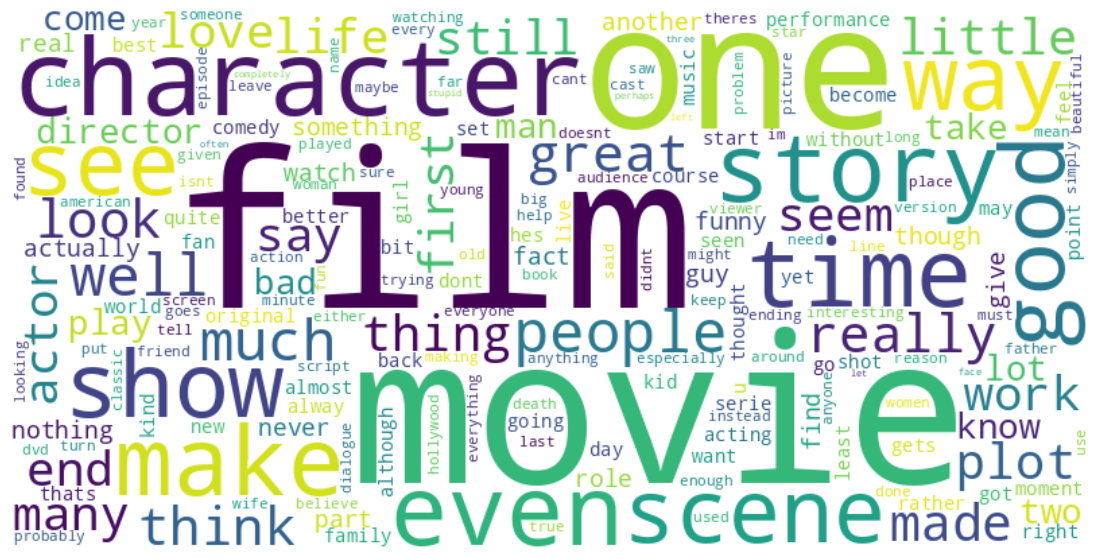

In [8]:
# 📌 Kütüphaneler
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from gensim.models import Word2Vec

# Görselleştirme
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1️⃣ Veri Yükleme
df = pd.read_csv("/content/IMDB Dataset.csv", engine='python')
# Label encode
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Hızlı test için küçük dataset seçiyoruz
df_small = df.sample(10000, random_state=42)
X = df_small['review']
y = df_small['sentiment']

# 2️⃣ Preprocessing Fonksiyonu
stop_words = set(stopwords.words('english'))

def clean_and_tokenize(text):
    # HTML tag temizle
    text = re.sub(r'<.*?>', ' ', text)
    # Küçük harf
    text = text.lower()
    # Noktalama ve özel karakterleri çıkar
    text = re.sub(r'[^a-z\s]', '', text)
    # Stopwords çıkar
    tokens = [word for word in text.split() if word not in stop_words]
    return tokens

# Token sütunu ekle
df_small['tokens'] = df_small['review'].apply(clean_and_tokenize)

# 3️⃣ Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df_small['review'], y, test_size=0.2, random_state=42)
X_train_tokens, X_test_tokens = train_test_split(df_small['tokens'], test_size=0.2, random_state=42)

# 4️⃣ MODEL 1: TF-IDF Unigram
tfidf_uni = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_train_uni = tfidf_uni.fit_transform(X_train_raw)
X_test_uni = tfidf_uni.transform(X_test_raw)

model_uni = LogisticRegression(solver='liblinear')
model_uni.fit(X_train_uni, y_train)
pred_uni = model_uni.predict(X_test_uni)
acc_uni = accuracy_score(y_test, pred_uni)

# 5️⃣ MODEL 2: TF-IDF Bigram (1-2 grams)
tfidf_bi = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_bi = tfidf_bi.fit_transform(X_train_raw)
X_test_bi = tfidf_bi.transform(X_test_raw)

model_bi = LogisticRegression(solver='liblinear')
model_bi.fit(X_train_bi, y_train)
pred_bi = model_bi.predict(X_test_bi)
acc_bi = accuracy_score(y_test, pred_bi)

# 6️⃣ MODEL 3: Word2Vec + Logistic Regression
# Word2Vec Eğitimi
w2v_model = Word2Vec(sentences=df_small['tokens'], vector_size=100, window=5, min_count=2, workers=4, sg=1)

# Her yorumun vektörünü ortalama alarak temsil et
import numpy as np

def get_w2v_vector(tokens, model, size):
    vec = np.zeros(size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

X_train_w2v = np.array([get_w2v_vector(tokens, w2v_model, 100) for tokens in X_train_tokens])
X_test_w2v = np.array([get_w2v_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

model_w2v = LogisticRegression(solver='liblinear')
model_w2v.fit(X_train_w2v, y_train)
pred_w2v = model_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, pred_w2v)

# 7️⃣ Sonuçları Karşılaştırma
print("📊 Accuracy Karşılaştırması:")
print("TF-IDF Unigram:", acc_uni)
print("TF-IDF Bigram:", acc_bi)
print("Word2Vec:", acc_w2v)

# 8️⃣ WordCloud Görselleştirme
all_words = [word for tokens in df_small['tokens'] for word in tokens]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Karşılaştırma (TF-IDF vs N-Gram vs Word2Vec) - SENTIMENT DATASET**

In [13]:
import pandas as pd

# 1️⃣ Dataset'i oku
df = pd.read_csv("/content/sentiment_data.csv")
print("Dataset boyutu:", df.shape)

# 2️⃣ Sütunları ve isimlerini gör
print("Sütun isimleri:", df.columns)

# 3️⃣ İlk 5 satırı incele
print(df.head())

# 4️⃣ Veri tiplerini ve eksik değerleri kontrol et
print(df.info())
print(df.isna().sum())

# 5️⃣ 'Sentiment' sütununda hangi benzersiz değerler var?
print("Sentiment sütunu unique değerleri:", df['Sentiment'].unique())

# 6️⃣ Özet istatistikler (numeric sütunlar için)
print(df.describe())

# 7️⃣ Kaç farklı sınıf var ve sayıları
print(df['Sentiment'].value_counts())

Dataset boyutu: (241145, 3)
Sütun isimleri: Index(['Unnamed: 0', 'Comment', 'Sentiment'], dtype='object')
   Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2
3           3  whenever go place doesn’t take apple pay doesn...          0
4           4  apple pay convenient secure easy use used kore...          2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB
None
Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64
S

In [14]:
import pandas as pd
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# CSV oku
df = pd.read_csv("/content/sentiment_data.csv")

# Gereksiz sütunu at
df = df.drop(columns=['Unnamed: 0'])

# Eksik yorumları at
df = df.dropna(subset=['Comment'])

# Stopwords seti
stop_words = set(stopwords.words('english'))

# Temizleme fonksiyonu
def clean_text(text):
    text = str(text)
    text = text.lower()  # küçük harfe çevir
    text = re.sub(r'<.*?>', ' ', text)  # HTML tagleri temizle
    text = re.sub(r'[^a-z\s]', '', text)  # noktalama ve özel karakterleri sil
    text = ' '.join([word for word in text.split() if word not in stop_words])  # stopwords temizle
    return text

# Comment sütununu temizle
df['Comment_clean'] = df['Comment'].apply(clean_text)

# Yeni boyut ve örnek
print("Temizlenmiş dataset boyutu:", df.shape)
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Temizlenmiş dataset boyutu: (240928, 3)
                                             Comment  Sentiment  \
0  lets forget apple pay required brand new iphon...          1   
1  nz retailers don’t even contactless credit car...          0   
2  forever acknowledge channel help lessons ideas...          2   
3  whenever go place doesn’t take apple pay doesn...          0   
4  apple pay convenient secure easy use used kore...          2   

                                       Comment_clean  
0  lets forget apple pay required brand new iphon...  
1  nz retailers dont even contactless credit card...  
2  forever acknowledge channel help lessons ideas...  
3  whenever go place doesnt take apple pay doesnt...  
4  apple pay convenient secure easy use used kore...  


/tmp/ipykernel_32863/829552800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


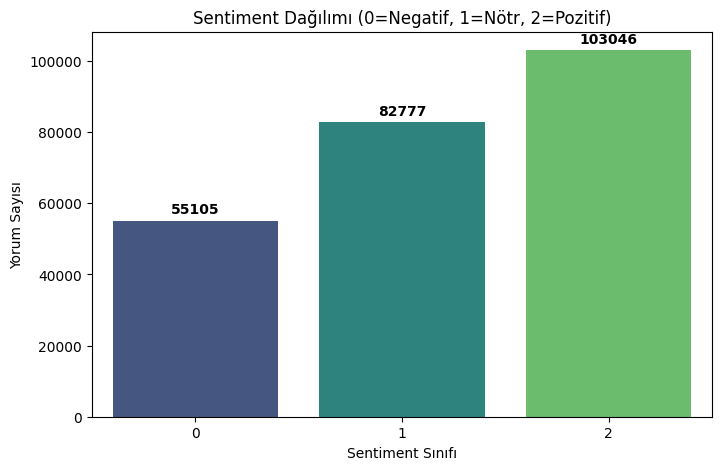

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sınıf sayısı
class_counts = df['Sentiment'].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title("Sentiment Dağılımı (0=Negatif, 1=Nötr, 2=Pozitif)")
plt.xlabel("Sentiment Sınıfı")
plt.ylabel("Yorum Sayısı")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 2000, str(v), ha='center', fontweight='bold')
plt.show()

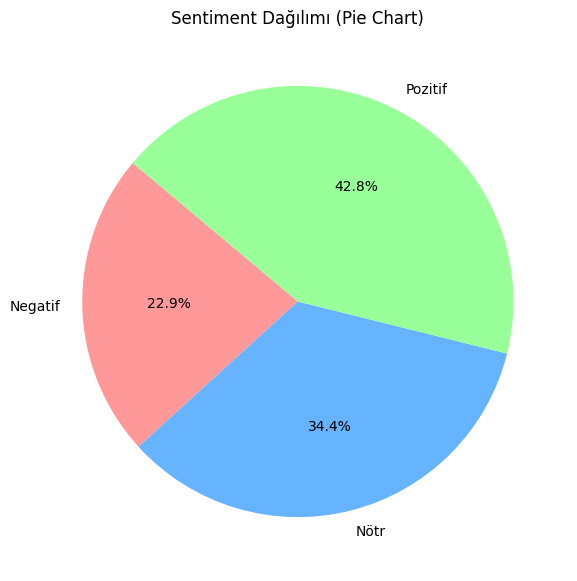

In [16]:
plt.figure(figsize=(7,7))
colors = ['#ff9999','#66b3ff','#99ff99']
plt.pie(class_counts.values, labels=['Negatif','Nötr','Pozitif'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Sentiment Dağılımı (Pie Chart)")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset boyutu: (241145, 3)


/tmp/ipykernel_32863/2838077140.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='magma')


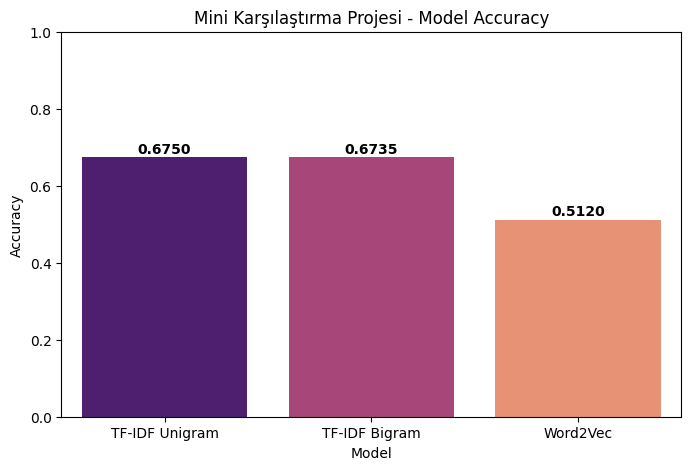

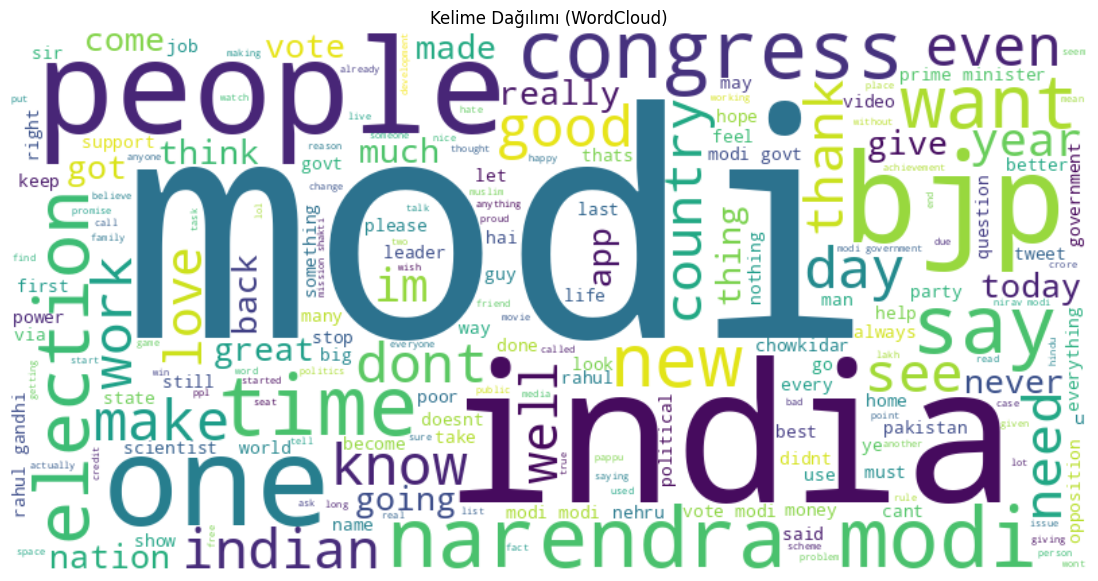

📊 Accuracy Karşılaştırması:
TF-IDF Unigram: 0.6750
TF-IDF Bigram: 0.6735
Word2Vec: 0.5120


In [17]:
# -----------------------------
# 1️⃣ Kütüphaneler
# -----------------------------
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from gensim.models import Word2Vec
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# -----------------------------
# 2️⃣ Dataset
# -----------------------------
df = pd.read_csv("/content/sentiment_data.csv")
print("Dataset boyutu:", df.shape)
df.head()

# -----------------------------
# 3️⃣ Temizleme ve Önişleme
# -----------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)          # HTML tagleri temizle
    text = text.lower()                         # küçük harf
    text = re.sub(r'[^a-z\s]', '', text)       # noktalama ve özel karakterleri çıkar
    text = ' '.join([w for w in text.split() if w not in stop_words])  # stopwords çıkar
    return text

df['clean_comment'] = df['Comment'].apply(clean_text)

# -----------------------------
# 4️⃣ Küçük Sample (Hızlı Deneme)
# -----------------------------
df_small = df.sample(10000, random_state=42)  # 10k örnek ile hızlandırıyoruz
X = df_small['clean_comment']
y = df_small['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 5️⃣ MODEL 1: TF-IDF Unigram
# -----------------------------
vec_uni = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_train_uni = vec_uni.fit_transform(X_train)
X_test_uni = vec_uni.transform(X_test)

model_uni = LogisticRegression(solver='liblinear')
model_uni.fit(X_train_uni, y_train)
pred_uni = model_uni.predict(X_test_uni)
acc_uni = accuracy_score(y_test, pred_uni)

# -----------------------------
# 6️⃣ MODEL 2: TF-IDF Bigram
# -----------------------------
vec_bi = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_bi = vec_bi.fit_transform(X_train)
X_test_bi = vec_bi.transform(X_test)

model_bi = LogisticRegression(solver='liblinear')
model_bi.fit(X_train_bi, y_train)
pred_bi = model_bi.predict(X_test_bi)
acc_bi = accuracy_score(y_test, pred_bi)

# -----------------------------
# 7️⃣ MODEL 3: Word2Vec
# -----------------------------
# Tokenize
df_small['tokens'] = df_small['clean_comment'].apply(lambda x: x.split())

# Word2Vec modeli
w2v_model = Word2Vec(sentences=df_small['tokens'], vector_size=100, window=5, min_count=2, workers=4, sg=1)

# Ortalama Word2Vec vektörleri (her yorum için)
def get_avg_w2v(tokens, model, vector_size):
    vec = []
    count = 0
    for word in tokens:
        if word in model.wv.key_to_index:
            vec.append(model.wv[word])
            count += 1
    if count > 0:
        return sum(vec)/count
    else:
        return [0]*vector_size

X_train_w2v = [get_avg_w2v(t.split(), w2v_model, 100) for t in X_train]
X_test_w2v = [get_avg_w2v(t.split(), w2v_model, 100) for t in X_test]

model_w2v = LogisticRegression(solver='liblinear')
model_w2v.fit(X_train_w2v, y_train)
pred_w2v = model_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, pred_w2v)

# -----------------------------
# 8️⃣ Sonuçların Görselleştirilmesi
# -----------------------------
results = pd.DataFrame({
    'Model': ['TF-IDF Unigram', 'TF-IDF Bigram', 'Word2Vec'],
    'Accuracy': [acc_uni, acc_bi, acc_w2v]
})

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='magma')
plt.ylim(0,1)
plt.title("Mini Karşılaştırma Projesi - Model Accuracy")
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# -----------------------------
# 9️⃣ WordCloud (Opsiyonel, kelime dağılımını görmek için)
# -----------------------------
all_words = [word for tokens in df_small['tokens'] for word in tokens]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Kelime Dağılımı (WordCloud)")
plt.show()

# -----------------------------
# 🔹 Accuracy Yazdır
# -----------------------------
print("📊 Accuracy Karşılaştırması:")
print(f"TF-IDF Unigram: {acc_uni:.4f}")
print(f"TF-IDF Bigram: {acc_bi:.4f}")
print(f"Word2Vec: {acc_w2v:.4f}")